In [1]:
import os
import numpy as np 
import pandas as pd
# import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from datetime import datetime
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU Available:  []


In [3]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [4]:
data = pd.read_csv("https://raw.githubusercontent.com/AjengSF015/Data-Apple-Stock-Price/refs/heads/main/Apple%20Stock%20Price.csv", delimiter=";")

data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,12/12/1980,128348,128906,128348,128348,99319,469033600
1,15/12/1980,122210,122210,121652,121652,94137,175884800
2,16/12/1980,113281,113281,112723,112723,87228,105728000
3,17/12/1980,115513,116071,115513,115513,89387,86441600
4,18/12/1980,118862,119420,118862,118862,91978,73449600


In [9]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

Text(0.5, 1.0, 'Price over time')

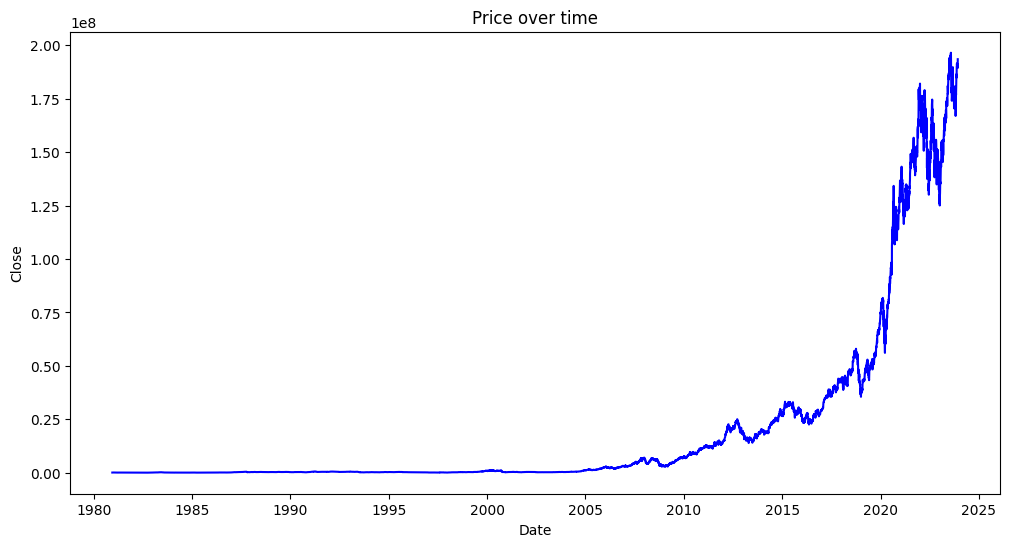

In [10]:
prediction = data.loc[
    (data['Date'] > datetime(2013,8,15)) &
    (data['Date'] < datetime(2013,12,5))
]

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'],color="blue")
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Price over time")

In [11]:
# Prepare for the LSTM Model (Sequential)
stock_close = data.filter(["Close"])
dataset = stock_close.values #convert to numpy array
training_data_len = int(np.ceil(len(dataset) * 0.95))

In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

In [13]:
training_data = scaled_data[:training_data_len]

In [14]:
X_train, y_train = [], []

In [15]:
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i,0])
    
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [16]:
len(X_train[0])
len(X_train)

10235

In [17]:
# Build the Model
model = keras.models.Sequential()

# Input Layer
model.add(keras.layers.InputLayer(input_shape=(60, 1)))

# First Layer
model.add(keras.layers.LSTM(64, return_sequences=True))

# Second Layer
model.add(keras.layers.LSTM(64, return_sequences=False))

# 3rd Layer (Dense)
model.add(keras.layers.Dense(128, activation="relu"))

# 4th Layer (Dropout)
model.add(keras.layers.Dropout(0.5))

# Final Output Layer
model.add(keras.layers.Dense(1))

model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])


training = model.fit(X_train, y_train, epochs=20, batch_size=32)

/Users/lorispolenz/Documents/GitHub/hslu/IAI_LSTM/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0771 - root_mean_squared_error: 0.1525
Epoch 2/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0554 - root_mean_squared_error: 0.0982
Epoch 3/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0523 - root_mean_squared_error: 0.1046
Epoch 4/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0477 - root_mean_squared_error: 0.0934
Epoch 5/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0431 - root_mean_squared_error: 0.0879
Epoch 6/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0422 - root_mean_squared_error: 0.0958
Epoch 7/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0409 - root_mean_squared_error: 0.0994
Epoch 8/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0378 - root_mean_squared_error: 0.0934
Epoch 9/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0373 - root_mean_squared_error: 0.0981
Epoch 10/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0364 - root_mean_s

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


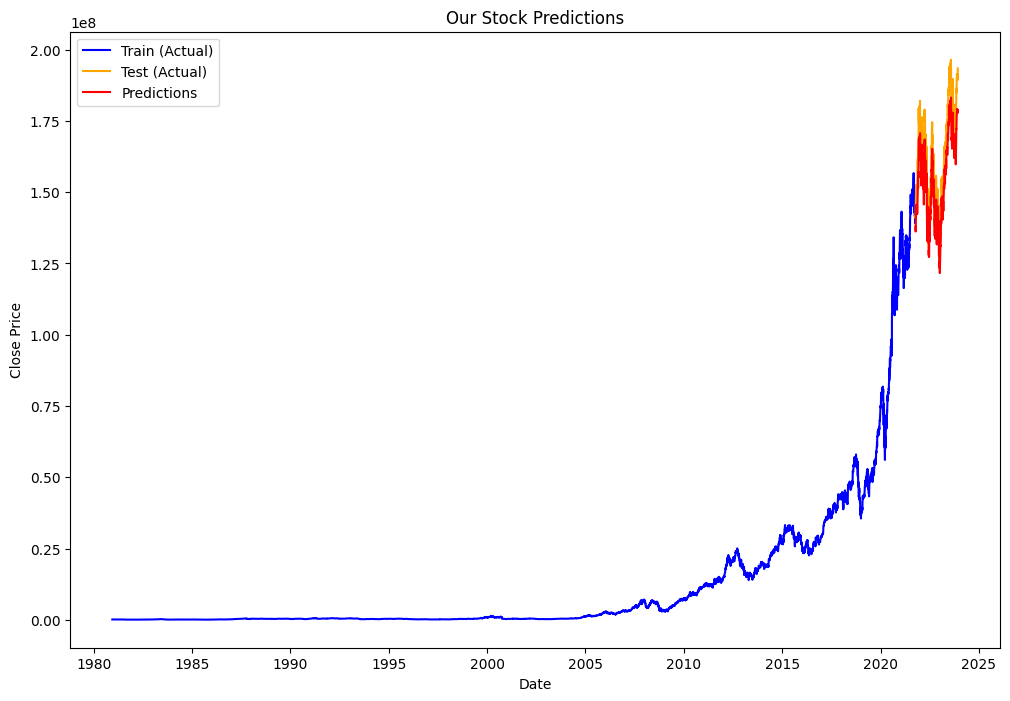

In [19]:
# Prep the test data
test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]


for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1 ))

# Make a Prediction
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)


# Plotting data
train = data[:training_data_len]
test =  data[training_data_len:]

test = test.copy()

test['Predictions'] = predictions


plt.figure(figsize=(12,8))
plt.plot(train['Date'], train['Close'], label="Train (Actual)", color='blue')
plt.plot(test['Date'], test['Close'], label="Test (Actual)", color='orange')
plt.plot(test['Date'], test['Predictions'], label="Predictions", color='red')
plt.title("Our Stock Predictions")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()